# Telco Customer Churn — Exploratory Data Analysis (EDA)
### Internship Project | Basic → Advanced, Industry-Standard Workflow

This notebook performs a complete EDA on the **Telco Customer Churn** dataset (IBM/Kaggle).
Every function is placed in its own cell with a short explanation of **what it does, why it's used in industry, and what to look for in the output**.

**Structure:**
1. Setup & Data Loading
2. Basic EDA (structure, types, missing values, duplicates)
3. Data Cleaning & Preprocessing
4. Univariate Analysis (single-variable)
5. Bivariate Analysis (variable vs Churn)
6. Multivariate Analysis (correlations, interactions)
7. Advanced EDA (statistical tests, outliers, feature engineering, multicollinearity)
8. Automated EDA reporting (industry tools)
9. Key Insights Summary


## 1. Setup & Data Loading

### 1.1 Import Libraries
- **pandas** → data loading, manipulation, tabular operations (industry standard for structured data)
- **numpy** → numerical operations, array math
- **matplotlib.pyplot / seaborn** → static statistical visualization (most common EDA plotting stack)
- **plotly.express** → interactive visualizations (used in dashboards/portfolios)
- **scipy.stats** → statistical tests (chi-square, t-test, skewness, etc.)
- **warnings** → suppress noisy warnings for a clean notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Display settings (industry practice: always widen output for readability)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


### 1.2 Load the Dataset — `pd.read_csv()`
Reads the CSV into a pandas DataFrame. This is always the first step of any EDA.
Update the path below to wherever your file is (e.g. `/mnt/user-data/uploads/WA_Fn-UseC_-Telco-Customer-Churn.csv`).

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Keep an untouched copy — good practice so raw data is always recoverable
df_raw = df.copy()


## 2. Basic EDA — Understanding Structure

### 2.1 `.head()` / `.tail()` / `.sample()`
- `.head(n)` → first n rows, quick sanity check of columns and values
- `.tail(n)` → last n rows, checks if data was loaded fully (no truncation)
- `.sample(n)` → random n rows, avoids bias from only looking at the top

In [3]:
display(df.head())
display(df.tail())
display(df.sample(5, random_state=42))


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


### 2.2 `.shape`
Returns (rows, columns). First thing you report about dataset size.

In [4]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Rows: 7043, Columns: 21


### 2.3 `.columns` and `.dtypes`
- `.columns` → lists all column names (check for typos/inconsistent naming)
- `.dtypes` → shows data type per column (object, int64, float64) — critical because
  Telco Churn has a well-known trap: `TotalCharges` looks numeric but is loaded as `object`.

In [5]:
print(df.columns.tolist())
print()
print(df.dtypes)


['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


### 2.4 `.info()`
Combines dtype, non-null counts, and memory usage in a single summary — the fastest way
to spot missing values and wrong types at once.

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 2.5 `.describe()`
- `.describe()` → summary statistics (mean, std, min, quartiles, max) for **numeric** columns
- `.describe(include='object')` → frequency, unique count, top category for **categorical** columns
This is the standard first look at distribution and scale of every variable.

In [7]:
display(df.describe())
display(df.describe(include='object'))


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### 2.6 `.isnull().sum()` and `.isna().mean()`
- `.isnull().sum()` → count of missing values per column
- `.isna().mean()*100` → percentage missing, more useful for deciding drop vs impute

In [8]:
missing = df.isnull().sum()
missing_pct = (df.isna().mean() * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)


,missing_count,missing_pct
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


### 2.7 `.duplicated().sum()`
Counts fully duplicated rows. Duplicate customers would bias churn rate calculations.

In [9]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate customerIDs: {df['customerID'].duplicated().sum()}")


Duplicate rows: 0
Duplicate customerIDs: 0


### 2.8 `.nunique()` and `.value_counts()`
- `.nunique()` → number of unique values per column, tells you which columns are categorical vs continuous vs ID-like
- `.value_counts()` → frequency table for a single categorical column (with `normalize=True` for proportions)

In [10]:
print(df.nunique())
print()
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).round(3) * 100)  # churn rate %


customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


## 3. Data Cleaning & Preprocessing

### 3.1 Fixing `TotalCharges` — `pd.to_numeric(errors='coerce')`
`TotalCharges` is stored as text with some blank strings (new customers with 0 tenure).
`errors='coerce'` converts invalid parsing into `NaN` instead of crashing — the standard safe conversion pattern.

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum(), "rows became NaN after conversion")
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


11 rows became NaN after conversion


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


### 3.2 Handling Missing Values — `.fillna()` / `.dropna()`
Since the NaNs correspond to `tenure == 0` (brand-new customers), the correct business logic
is to fill `TotalCharges` with 0, not the mean (which would be misleading for new customers).

In [12]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
assert df['TotalCharges'].isnull().sum() == 0


### 3.3 Standardizing Categorical Text — `.replace()` / `.str.strip()`
Some Telco Churn columns use `'No internet service'` / `'No phone service'` as a third category
that is functionally the same as `'No'` for many analyses. Standardize for cleaner grouping.

In [13]:
cols_to_clean = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                  'TechSupport','StreamingTV','StreamingMovies']
for c in cols_to_clean:
    df[c] = df[c].replace({'No internet service': 'No'})

df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})


### 3.4 Encoding the Target — mapping `Yes/No` to `1/0`
Numeric target makes correlation, groupby-mean churn-rate, and modeling straightforward.

In [14]:
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})
df[['Churn', 'Churn_Flag']].head()


,Churn,Churn_Flag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


### 3.5 Data Types Audit — `.astype()`
`SeniorCitizen` is 0/1 but stored as int; converting to category-like for plotting readability.

In [15]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
df['SeniorCitizen'].value_counts()


SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

## 4. Univariate Analysis (One Variable at a Time)

### 4.1 Numeric Distribution — `sns.histplot()` / `.hist()`
Shows the shape (skew, spread, modality) of a single numeric variable.
`tenure`, `MonthlyCharges`, `TotalCharges` are the three numeric columns of interest.

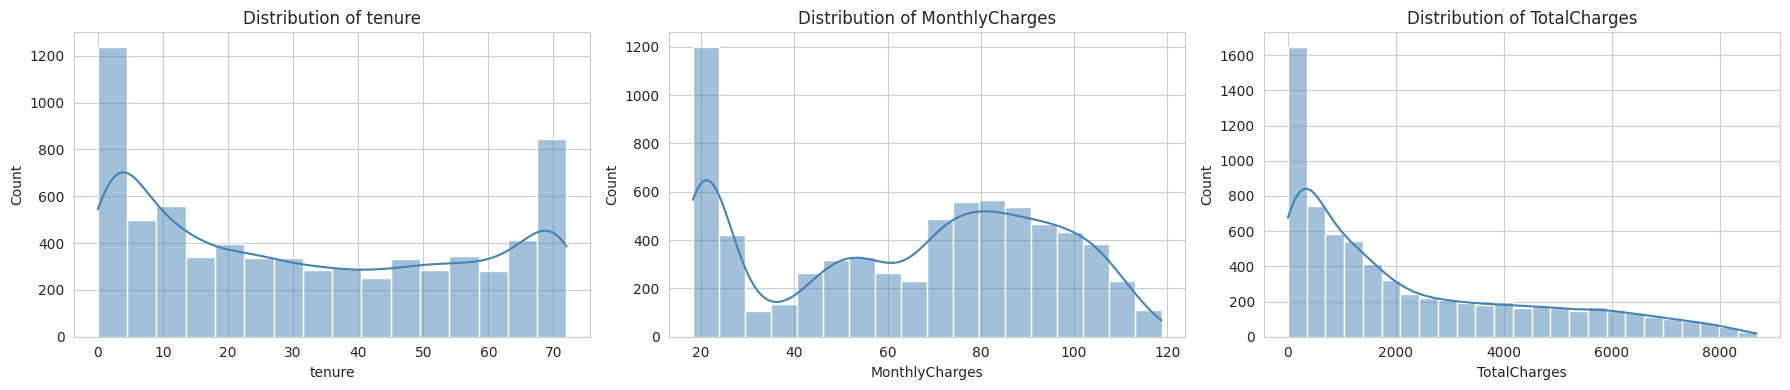

In [16]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


### 4.2 Boxplot — `sns.boxplot()`
Visualizes median, quartiles, and outliers for numeric columns in one view.

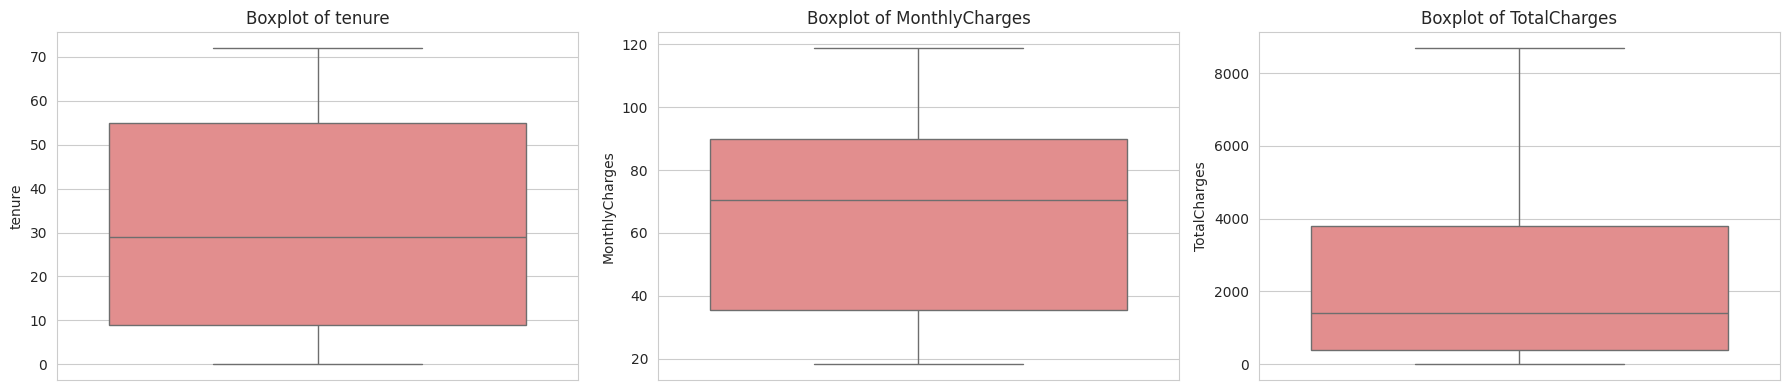

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


### 4.3 Categorical Counts — `sns.countplot()`
Standard bar chart for a single categorical column's frequency.

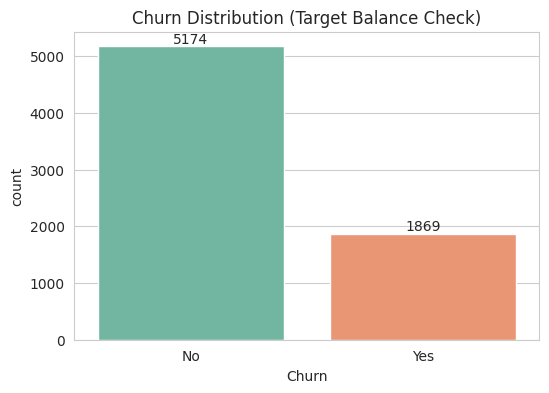

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2', ax=ax)
ax.set_title('Churn Distribution (Target Balance Check)')
for container in ax.containers:
    ax.bar_label(container)
plt.show()


### 4.4 Skewness & Kurtosis — `.skew()` / `.kurt()`
- **Skewness** → measures asymmetry (0 = symmetric, >0 = right-tailed)
- **Kurtosis** → measures "tailedness" / outlier-proneness relative to a normal distribution
Used to decide if a transform (log, sqrt) is needed before modeling.

In [19]:
for col in num_cols:
    print(f"{col}: skew={df[col].skew():.2f}, kurtosis={df[col].kurt():.2f}")


tenure: skew=0.24, kurtosis=-1.39
MonthlyCharges: skew=-0.22, kurtosis=-1.26
TotalCharges: skew=0.96, kurtosis=-0.23


## 5. Bivariate Analysis (Variable vs Churn)

### 5.1 `.groupby().mean()` — Churn Rate by Category
The core industry pattern for churn analysis: group by a categorical column and compute the
mean of the numeric `Churn_Flag` (mean of 0/1 = proportion that churned).

In [20]:
cat_cols = ['gender','SeniorCitizen','Partner','Dependents','Contract',
            'PaperlessBilling','PaymentMethod','InternetService']

for col in cat_cols:
    print(df.groupby(col)['Churn_Flag'].mean().round(3).sort_values(ascending=False))
    print('-'*40)


gender
Female    0.269
Male      0.262
Name: Churn_Flag, dtype: float64
----------------------------------------
SeniorCitizen
Yes    0.417
No     0.236
Name: Churn_Flag, dtype: float64
----------------------------------------
Partner
No     0.330
Yes    0.197
Name: Churn_Flag, dtype: float64
----------------------------------------
Dependents
No     0.313
Yes    0.155
Name: Churn_Flag, dtype: float64
----------------------------------------
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn_Flag, dtype: float64
----------------------------------------
PaperlessBilling
Yes    0.336
No     0.163
Name: Churn_Flag, dtype: float64
----------------------------------------
PaymentMethod
Electronic check             0.453
Mailed check                 0.191
Bank transfer (automatic)    0.167
Credit card (automatic)      0.152
Name: Churn_Flag, dtype: float64
----------------------------------------
InternetService
Fiber optic    0.419
DSL            0.

### 5.2 `pd.crosstab()` — Contingency Tables
Cross-tabulates two categorical variables with counts or normalized percentages —
the standard way to inspect the relationship between two categorical fields.

In [21]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index').round(3) * 100


Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


### 5.3 Categorical vs Churn — `sns.countplot(hue=...)`
Stacked/grouped bar charts to visually compare churn across categories.

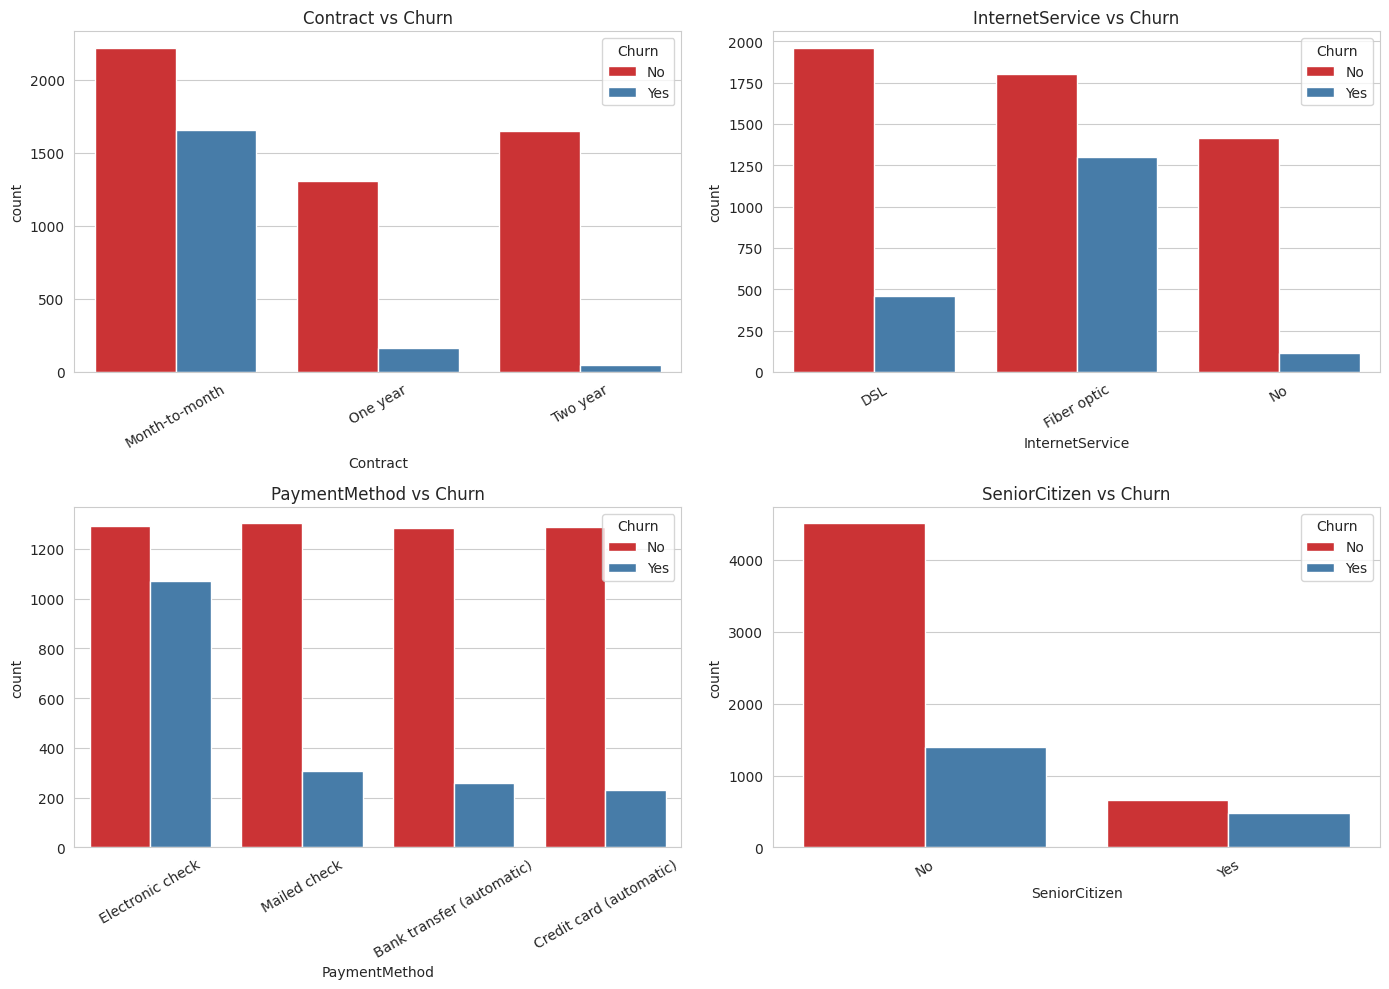

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax, palette='Set1')
    ax.set_title(f'{col} vs Churn')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### 5.4 Numeric vs Churn — `sns.boxplot(x=Churn, y=numeric)`
Compares the distribution of a numeric variable across churned vs retained customers.

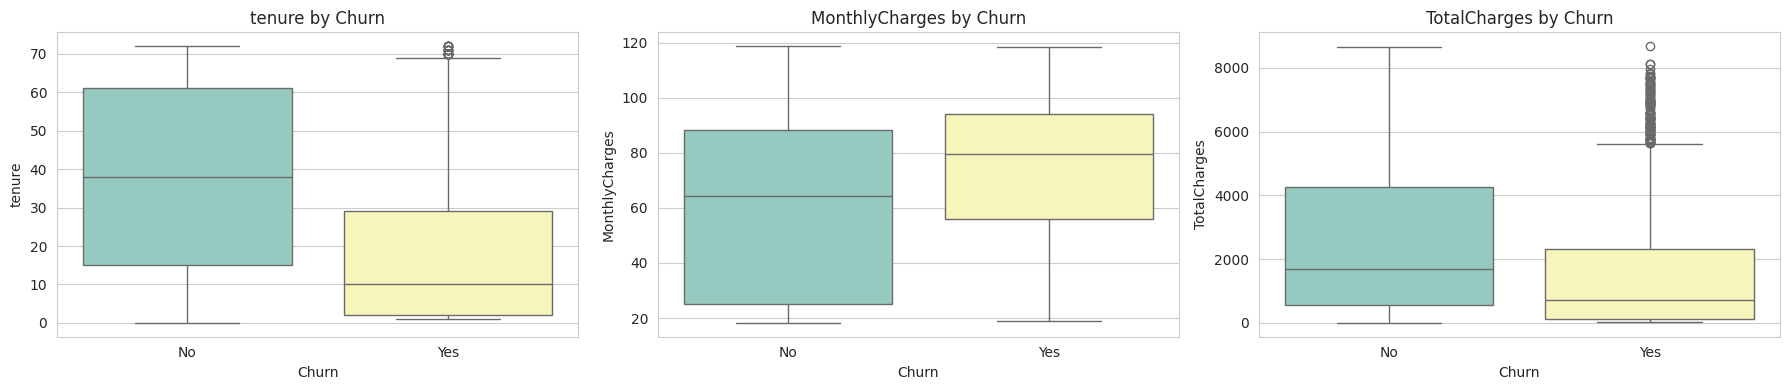

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax, palette='Set3')
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()


### 5.5 KDE Overlay — `sns.kdeplot(hue=...)`
Smooth density comparison; often clearer than boxplots for spotting where churn concentrates
(e.g. churn is famously concentrated in low-tenure customers).

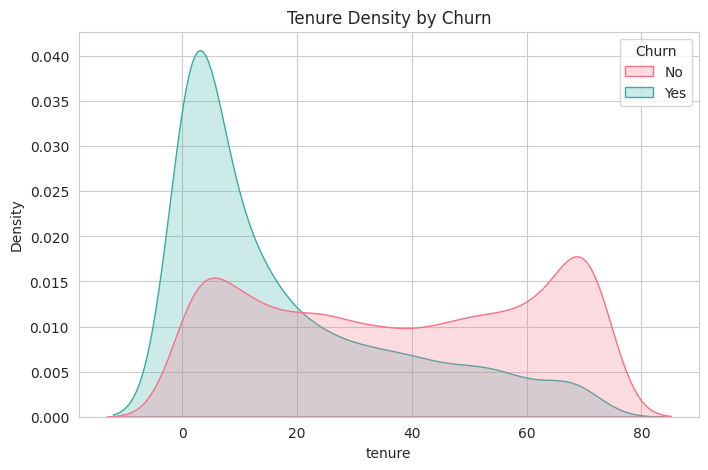

In [24]:
fig, ax = plt.subplots(figsize=(8,5))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='husl', ax=ax)
ax.set_title('Tenure Density by Churn')
plt.show()


## 6. Multivariate Analysis

### 6.1 Correlation Matrix — `.corr()`
Pearson correlation between all numeric columns (including the encoded target)
to spot linear relationships and multicollinearity risk.

In [25]:
corr = df[['tenure','MonthlyCharges','TotalCharges','Churn_Flag']].corr()
corr


,tenure,MonthlyCharges,TotalCharges,Churn_Flag
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
Churn_Flag,-0.352229,0.193356,-0.198324,1.000000


### 6.2 Heatmap — `sns.heatmap()`
Visualizes the correlation matrix — the standard way to present correlations in reports.

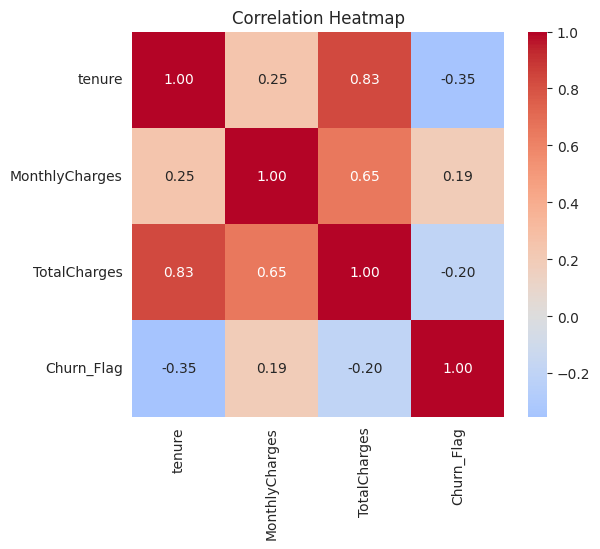

In [26]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Heatmap')
plt.show()


### 6.3 Pairplot — `sns.pairplot()`
Grid of pairwise scatterplots + histograms for numeric variables, colored by Churn —
useful for spotting clusters/separability at a glance.

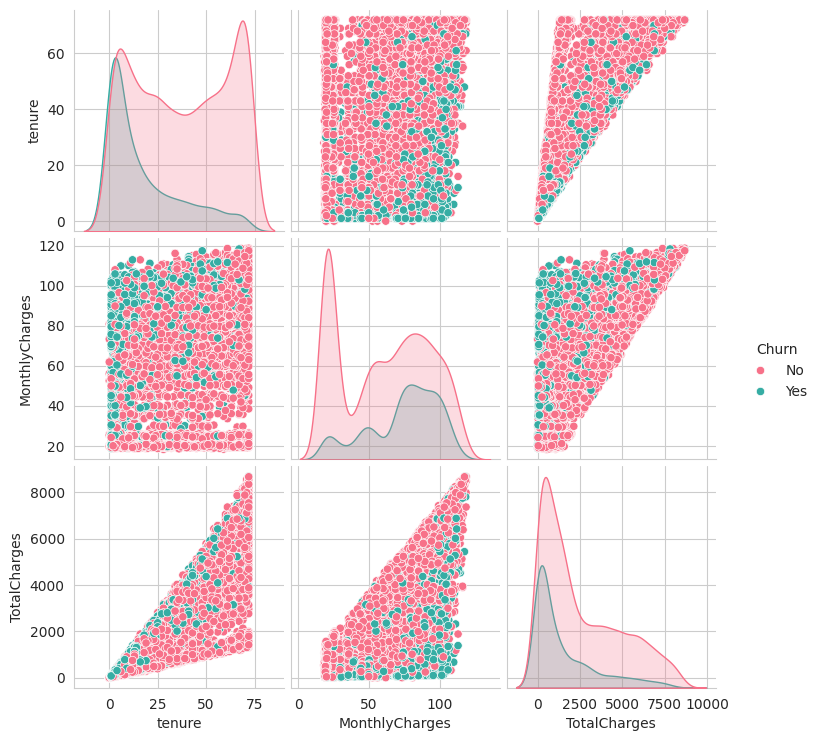

In [27]:
sns.pairplot(df[['tenure','MonthlyCharges','TotalCharges','Churn']], hue='Churn', diag_kind='kde', palette='husl')
plt.show()


### 6.4 Pivot Table — `pd.pivot_table()`
Multi-dimensional aggregation — e.g. average monthly charges by Contract type AND Internet
Service, split by churn. This is the Excel-style aggregation used constantly in industry reporting.

In [28]:
pd.pivot_table(df, values='MonthlyCharges', index='Contract',
               columns='Churn', aggfunc='mean').round(2)


Churn,No,Yes
Contract,,
Month-to-month,61.46,73.02
One year,62.51,85.05
Two year,60.01,86.78


### 6.5 Interactive Visualization — `plotly.express`
Interactive charts (hover tooltips, zoom) are the industry standard for dashboards/stakeholder
presentations, as opposed to static matplotlib for reports.

In [29]:
fig = px.box(df, x='Contract', y='MonthlyCharges', color='Churn',
             title='Monthly Charges by Contract Type and Churn')
fig.show()


## 7. Advanced EDA — Statistical & Feature-Level Analysis

### 7.1 Chi-Square Test of Independence — `scipy.stats.chi2_contingency()`
Tests whether a categorical variable (e.g. Contract) is statistically associated with Churn.
A p-value < 0.05 means the association is unlikely to be due to chance — this is how you
back up "this variable matters" claims with statistics, not just visuals.

In [30]:
from scipy.stats import chi2_contingency

for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f"{col}: chi2={chi2:.2f}, p-value={p:.4f} -> {'SIGNIFICANT' if p < 0.05 else 'not significant'}")


gender: chi2=0.48, p-value=0.4866 -> not significant
SeniorCitizen: chi2=159.43, p-value=0.0000 -> SIGNIFICANT
Partner: chi2=158.73, p-value=0.0000 -> SIGNIFICANT
Dependents: chi2=189.13, p-value=0.0000 -> SIGNIFICANT
Contract: chi2=1184.60, p-value=0.0000 -> SIGNIFICANT
PaperlessBilling: chi2=258.28, p-value=0.0000 -> SIGNIFICANT
PaymentMethod: chi2=648.14, p-value=0.0000 -> SIGNIFICANT
InternetService: chi2=732.31, p-value=0.0000 -> SIGNIFICANT


### 7.2 Independent t-test — `scipy.stats.ttest_ind()`
Tests whether the mean of a numeric variable (e.g. tenure) differs significantly between
churned and non-churned customers.

In [31]:
from scipy.stats import ttest_ind

churned = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']
t_stat, p_val = ttest_ind(churned, retained, equal_var=False)
print(f"t-statistic={t_stat:.2f}, p-value={p_val:.6f}")


t-statistic=-34.82, p-value=0.000000


### 7.3 Outlier Detection — IQR method
The Interquartile Range method is the standard, distribution-free way to flag outliers:
anything beyond `Q1 - 1.5*IQR` or `Q3 + 1.5*IQR` is flagged.

In [32]:
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return series[(series < lower) | (series > upper)]

for col in num_cols:
    outliers = iqr_outliers(df[col])
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")


tenure: 0 outliers (0.00%)
MonthlyCharges: 0 outliers (0.00%)
TotalCharges: 0 outliers (0.00%)


### 7.4 Z-score Outlier Detection — `scipy.stats.zscore()`
Alternative outlier method assuming a roughly normal distribution; |z| > 3 is a common
industry threshold for flagging extreme values.

In [33]:
from scipy.stats import zscore

z_scores = df[num_cols].apply(zscore)
outlier_mask = (z_scores.abs() > 3).any(axis=1)
print(f"Rows flagged as outliers by z-score: {outlier_mask.sum()}")


Rows flagged as outliers by z-score: 0


### 7.5 Feature Engineering — creating business-relevant features
Industry EDA usually goes beyond raw columns to derive new signal, e.g. tenure buckets and
average revenue per month of tenure.

In [34]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,60,72],
                             labels=['0-1yr','1-2yr','2-4yr','4-5yr','5-6yr'])
df['avg_monthly_spend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

df.groupby('tenure_group')['Churn_Flag'].mean().round(3)


tenure_group
0-1yr    0.477
1-2yr    0.287
2-4yr    0.204
4-5yr    0.144
5-6yr    0.066
Name: Churn_Flag, dtype: float64

### 7.6 Multicollinearity Check — Variance Inflation Factor (VIF)
VIF quantifies how much a numeric feature is linearly explained by the other numeric features.
VIF > 5 (or 10) signals problematic multicollinearity before feeding features into a model —
a standard pre-modeling EDA step.

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['tenure','MonthlyCharges','TotalCharges']].dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data


,feature,VIF
0,tenure,6.332328
1,MonthlyCharges,3.355660
2,TotalCharges,8.075070


### 7.7 One-Hot Encoding — `pd.get_dummies()`
Converts categorical variables into numeric dummy columns — the standard final EDA→modeling
handoff step, so the dataset is ready for a churn-prediction model.

In [36]:
df_encoded = pd.get_dummies(df.drop(columns=['customerID','Churn']), drop_first=True)
df_encoded.shape


(7043, 29)

### 7.8 Feature Importance Preview — correlation with target after encoding
A quick, model-free way to rank which encoded features are most associated with churn,
before running a full model.

In [37]:
target_corr = df_encoded.corr()['Churn_Flag'].sort_values(ascending=False)
target_corr.head(10)


Churn_Flag                        1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
avg_monthly_spend                 0.193301
PaperlessBilling_Yes              0.191825
SeniorCitizen_Yes                 0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
Name: Churn_Flag, dtype: float64

## 8. Automated EDA Reporting (Industry Tools)

For fast, comprehensive EDA reports, industry practitioners often use auto-EDA libraries.
These generate a full HTML report (distributions, correlations, missing values, alerts) in one line —
useful as a starting point or a supplement to manual analysis, not a replacement for it.

- **ydata-profiling** (formerly pandas-profiling): `ProfileReport(df).to_file('report.html')`
- **Sweetviz**: `sweetviz.analyze(df).show_html('report.html')`
- **D-Tale**: launches an interactive web app for live data exploration

Install with `pip install ydata-profiling sweetviz` (not run here to keep the notebook light).

In [38]:
# Example (uncomment to run, requires ydata-profiling installed):
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, title="Telco Churn EDA Report", explorative=True)
# profile.to_file("telco_churn_eda_report.html")


## 9. Key Insights Summary (fill in after running)

Typical findings on this dataset (verify against your own output):
- Overall churn rate is roughly **26–27%** — a moderately imbalanced target.
- **Month-to-month contracts** churn far more than one/two-year contracts.
- **Low tenure** customers (new customers) churn significantly more.
- **Fiber optic internet** customers churn more than DSL or no-internet customers.
- **Higher MonthlyCharges** is associated with higher churn.
- Customers **without OnlineSecurity/TechSupport** churn more — these look like upsell opportunities.
- `TotalCharges` is highly correlated with `tenure` (expected, since it accumulates over time) — a multicollinearity note for modeling.

### Suggested next steps
1. Handle class imbalance (SMOTE / class_weight) before modeling.
2. Build a baseline classifier (Logistic Regression) then compare to tree-based models (Random Forest, XGBoost).
3. Use the chi-square/t-test results above to justify feature selection in your report.
